In [ ]:
#!/usr/bin/env python3
"""
TorajiGrade - Advanced Training Script
=======================================

Computer Vision training pipeline for:
"TorajiGrade: Penilai Konsistensi Tingkat Sangrai dan
 Deteksi Biji Mentah Kopi Toraja Berbasis Computer Vision"

Target:
- MobileNetV3 Small
- 4 classes: Dark, Green, Light, Medium
- Classifier-only fine-tuning
- CUDA if available, otherwise CPU
- Robust handling of corrupted/non-readable images
- Best-model checkpointing based on validation accuracy
- Training metrics visualization

Expected dataset structure:
.
├── train/
│   ├── Dark/
│   ├── Green/
│   ├── Light/
│   └── Medium/
└── test/
    ├── Dark/
    ├── Green/
    ├── Light/
    └── Medium/
"""

from __future__ import annotations

import copy
import os
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageFile, UnidentifiedImageError
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm




In [ ]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------

SEED = 42

IMAGE_SIZE = (224, 224)
NUM_CLASSES = 4

BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3

NUM_WORKERS = min(2, os.cpu_count() or 1)

MODEL_OUTPUT = Path("best_torajigrade_model.pth")
METRICS_OUTPUT = Path("training_metrics.png")

EXPECTED_CLASSES = ["Dark", "Green", "Light", "Medium"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [ ]:
# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------

def set_seed(seed: int = SEED) -> None:
    """Set deterministic/random seeds where possible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Deterministic behavior can reduce performance slightly,
    # but improves reproducibility for an MVP/competition pipeline.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# -----------------------------------------------------------------------------
# Dataset discovery
# -----------------------------------------------------------------------------

def resolve_dataset_root() -> Path:
    """
    Resolve dataset root from Google Drive.

    Expected structure:
    /content/drive/MyDrive/Dataset/dataset-AIC/
    ├── train/
    │   ├── Dark/
    │   ├── Green/
    │   ├── Light/
    │   └── Medium/
    └── test/
        ├── Dark/
        ├── Green/
        ├── Light/
        └── Medium/
    """
    dataset_root = Path(
        "/content/drive/MyDrive/Dataset/dataset-AIC"
    )

    train_dir = dataset_root / "train"
    test_dir = dataset_root / "test"

    if not dataset_root.is_dir():
        raise FileNotFoundError(
            f"Dataset root tidak ditemukan: {dataset_root}"
        )

    if not train_dir.is_dir():
        raise FileNotFoundError(
            f"Folder train tidak ditemukan: {train_dir}"
        )

    if not test_dir.is_dir():
        raise FileNotFoundError(
            f"Folder test tidak ditemukan: {test_dir}"
        )

    return dataset_root.resolve()

In [ ]:
# -----------------------------------------------------------------------------
# Corrupted image protection
# -----------------------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = True


def validate_image_file(path: str) -> bool:
    """
    Validate an image file with PIL.

    Returns False for corrupt, truncated, unsupported, or unreadable images.
    """
    try:
        with Image.open(path) as image:
            image.verify()
        return True
    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
        SyntaxError,
    ):
        return False

In [ ]:
class SafeImageFolder(datasets.ImageFolder):
    """
    ImageFolder variant that filters unreadable/corrupted images during
    dataset initialization.

    This prevents a single damaged image from terminating an epoch.
    """

    def __init__(self, root: str | Path, transform=None):
        self.invalid_files: List[str] = []

        super().__init__(
            root=str(root),
            transform=transform,
        )

    def make_dataset(
        self,
        directory: str,
        class_to_idx: Dict[str, int],
        extensions: Optional[Tuple[str, ...]] = None,
        is_valid_file=None,
        allow_empty: bool = False, # Add this parameter
    ):
        dataset = super().make_dataset(
            directory=directory,
            class_to_idx=class_to_idx,
            extensions=extensions,
            is_valid_file=is_valid_file,
            allow_empty=allow_empty, # Pass it to super
        )

        valid_samples = []

        for path, class_index in dataset:
            if validate_image_file(path):
                valid_samples.append((path, class_index))
            else:
                self.invalid_files.append(path)

        return valid_samples

In [ ]:
# -----------------------------------------------------------------------------
# Data transforms
# -----------------------------------------------------------------------------

def build_transforms() -> Tuple[transforms.Compose, transforms.Compose]:
    train_transform = transforms.Compose(
        [
            transforms.Resize(IMAGE_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=IMAGENET_MEAN,
                std=IMAGENET_STD,
            ),
        ]
    )

    val_transform = transforms.Compose(
        [
            transforms.Resize(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=IMAGENET_MEAN,
                std=IMAGENET_STD,
            ),
        ]
    )

    return train_transform, val_transform

In [ ]:
# -----------------------------------------------------------------------------
# Dataloader
# -----------------------------------------------------------------------------

def safe_collate(
    batch: List[Optional[Tuple[torch.Tensor, int]]],
) -> Optional[Tuple[torch.Tensor, torch.Tensor]]:
    """
    Safety collate function.

    It filters None samples if ImageFolder ever returns one unexpectedly.
    """
    batch = [item for item in batch if item is not None]

    if not batch:
        return None

    images, labels = zip(*batch)

    return (
        torch.stack(images, dim=0),
        torch.tensor(labels, dtype=torch.long),
    )


def build_dataloaders(
    train_dir: Path,
    val_dir: Path,
) -> Tuple[DataLoader, DataLoader, Dict[str, int], Dict[str, int]]:
    train_transform, val_transform = build_transforms()

    train_dataset = SafeImageFolder(
        root=train_dir,
        transform=train_transform,
    )

    val_dataset = SafeImageFolder(
        root=val_dir,
        transform=val_transform,
    )

    print(f"Train classes: {train_dataset.class_to_idx}")
    print(f"Val classes:   {val_dataset.class_to_idx}")

    expected_mapping = {
        class_name: index
        for index, class_name in enumerate(EXPECTED_CLASSES)
    }

    if train_dataset.class_to_idx != expected_mapping:
        raise RuntimeError(
            f"Mapping class train tidak sesuai.\n"
            f"Expected: {expected_mapping}\n"
            f"Actual:   {train_dataset.class_to_idx}"
        )

    if val_dataset.class_to_idx != expected_mapping:
        raise RuntimeError(
            f"Mapping class validation/test tidak sesuai.\n"
            f"Expected: {expected_mapping}\n"
            f"Actual:   {val_dataset.class_to_idx}"
        )

    if train_dataset.invalid_files:
        print(
            f"[WARNING] Train: {len(train_dataset.invalid_files)} "
            "file corrupt/tidak dapat dibaca dilewati."
        )

    if val_dataset.invalid_files:
        print(
            f"[WARNING] Validation: {len(val_dataset.invalid_files)} "
            "file corrupt/tidak dapat dibaca dilewati."
        )

    if len(train_dataset) == 0:
        raise RuntimeError("Training dataset kosong setelah filtering.")

    if len(val_dataset) == 0:
        raise RuntimeError("Validation dataset kosong setelah filtering.")

    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=NUM_WORKERS > 0,
        collate_fn=safe_collate,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=NUM_WORKERS > 0,
        collate_fn=safe_collate,
    )

    return (
        train_loader,
        val_loader,
        train_dataset.class_to_idx,
        val_dataset.class_to_idx,
    )

In [ ]:
# -----------------------------------------------------------------------------
# Model
# -----------------------------------------------------------------------------

def build_model(
    num_classes: int = NUM_CLASSES,
) -> nn.Module:
    """
    Build MobileNetV3 Small according to the required architecture.

    Backbone:
        MobileNet_V3_Small_Weights.DEFAULT

    Fine-tuning:
        Only model.classifier[3]
    """
    model = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.DEFAULT
    )

    # Freeze entire backbone/model.
    for param in model.parameters():
        param.requires_grad = False

    # Replace only the final classifier layer.
    in_features = model.classifier[3].in_features

    model.classifier[3] = nn.Linear(
        in_features=in_features,
        out_features=num_classes,
    )

    # Enable gradients only for the new final classifier layer.
    for param in model.classifier[3].parameters():
        param.requires_grad = True

    return model

In [ ]:
# -----------------------------------------------------------------------------
# Training / validation epoch
# -----------------------------------------------------------------------------

def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: Optional[optim.Optimizer] = None,
    phase: str = "train",
) -> Tuple[float, float]:
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    running_samples = 0

    progress = tqdm(
        loader,
        desc=f"{phase.capitalize():<5}",
        leave=False,
        dynamic_ncols=True,
    )

    for batch in progress:
        if batch is None:
            continue

        images, labels = batch

        images = images.to(
            device,
            non_blocking=True,
        )
        labels = labels.to(
            device,
            non_blocking=True,
        )

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1)

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        running_correct += (
            predictions == labels
        ).sum().item()
        running_samples += batch_size

        current_loss = (
            running_loss / running_samples
            if running_samples > 0
            else 0.0
        )

        current_accuracy = (
            running_correct / running_samples
            if running_samples > 0
            else 0.0
        )

        progress.set_postfix(
            loss=f"{current_loss:.4f}",
            acc=f"{current_accuracy:.4f}",
        )

    if running_samples == 0:
        raise RuntimeError(
            f"Tidak ada sample valid yang dapat diproses pada phase {phase}."
        )

    epoch_loss = running_loss / running_samples
    epoch_accuracy = running_correct / running_samples

    return epoch_loss, epoch_accuracy

In [ ]:
# -----------------------------------------------------------------------------
# Metrics visualization
# -----------------------------------------------------------------------------

def plot_training_history(
    history: Dict[str, List[float]],
    output_path: Path,
) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 5),
    )

    # Loss subplot
    axes[0].plot(
        epochs,
        history["train_loss"],
        label="Train Loss",
        linewidth=2,
    )
    axes[0].plot(
        epochs,
        history["val_loss"],
        label="Validation Loss",
        linewidth=2,
    )
    axes[0].set_title("TorajiGrade Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross Entropy Loss")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    # Accuracy subplot
    axes[1].plot(
        epochs,
        history["train_accuracy"],
        label="Train Accuracy",
        linewidth=2,
    )
    axes[1].plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy",
        linewidth=2,
    )
    axes[1].set_title("TorajiGrade Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.close(fig)

In [ ]:
# -----------------------------------------------------------------------------
# Main training pipeline
# -----------------------------------------------------------------------------

def main() -> None:
    set_seed()

    print("=" * 72)
    print("TorajiGrade - MobileNetV3 Small Training")
    print("=" * 72)

    dataset_root = resolve_dataset_root()

    train_dir = dataset_root / "train"
    val_dir = dataset_root / "test"

    print(f"Dataset root : {dataset_root}")
    print(f"Train path   : {train_dir}")
    print(f"Val/Test path: {val_dir}")

    # -------------------------------------------------------------------------
    # Device routing
    # -------------------------------------------------------------------------

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print(f"Device       : {device}")

    if device.type == "cuda":
        print(f"GPU          : {torch.cuda.get_device_name(0)}")

    # -------------------------------------------------------------------------
    # Datasets
    # -------------------------------------------------------------------------

    train_loader, val_loader, _, _ = build_dataloaders(
        train_dir=train_dir,
        val_dir=val_dir,
    )

    print(f"Train samples: {len(train_loader.dataset)}")
    print(f"Val samples  : {len(val_loader.dataset)}")

    # -------------------------------------------------------------------------
    # Model
    # -------------------------------------------------------------------------

    model = build_model(NUM_CLASSES)
    model = model.to(device)

    # Ensure only classifier[3] has gradients.
    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    if not trainable_parameters:
        raise RuntimeError(
            "Tidak ada parameter trainable pada model."
        )

    print("\nTrainable parameters:")
    for name, parameter in model.named_parameters():
        if parameter.requires_grad:
            print(f"  - {name}: {tuple(parameter.shape)}")

    # -------------------------------------------------------------------------
    # Optimization
    # -------------------------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        trainable_parameters,
        lr=LEARNING_RATE,
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS,
    )

    # -------------------------------------------------------------------------
    # History / checkpoint tracking
    # -------------------------------------------------------------------------

    history: Dict[str, List[float]] = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "learning_rate": [],
    }

    best_val_accuracy = -float("inf")
    best_epoch = 0
    best_state_dict: Optional[Dict[str, torch.Tensor]] = None

    # -------------------------------------------------------------------------
    # Training
    # -------------------------------------------------------------------------

    for epoch in range(1, NUM_EPOCHS + 1):
        print()
        print("-" * 72)
        print(f"Epoch {epoch}/{NUM_EPOCHS}")

        current_lr = optimizer.param_groups[0]["lr"]

        train_loss, train_accuracy = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            device=device,
            optimizer=optimizer,
            phase="train",
        )

        val_loss, val_accuracy = run_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            optimizer=None,
            phase="val",
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)
        history["learning_rate"].append(current_lr)

        scheduler.step()

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy * 100:.2f}%"
        )

        print(
            f"Val Loss:   {val_loss:.4f} | "
            f"Val Acc:   {val_accuracy * 100:.2f}%"
        )

        print(f"Learning Rate: {current_lr:.8f}")

        # ---------------------------------------------------------------------
        # Save ONLY when validation accuracy improves.
        # ---------------------------------------------------------------------

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch

            best_state_dict = copy.deepcopy(
                model.state_dict()
            )

            # Save pure model weights only.
            torch.save(
                best_state_dict,
                MODEL_OUTPUT,
            )

            print(
                f"[CHECKPOINT] Validation accuracy improved -> "
                f"{best_val_accuracy * 100:.2f}%"
            )
            print(
                f"[CHECKPOINT] Saved: {MODEL_OUTPUT.resolve()}"
            )

    # -------------------------------------------------------------------------
    # Visualization
    # -------------------------------------------------------------------------

    plot_training_history(
        history=history,
        output_path=METRICS_OUTPUT,
    )

    print()
    print("=" * 72)
    print("TRAINING COMPLETE")
    print("=" * 72)
    print(
        f"Best validation accuracy: "
        f"{best_val_accuracy * 100:.2f}%"
    )
    print(f"Best epoch              : {best_epoch}")
    print(f"Model                   : {MODEL_OUTPUT.resolve()}")
    print(f"Metrics                 : {METRICS_OUTPUT.resolve()}")

In [ ]:
if __name__ == "__main__":
    main()

TorajiGrade - MobileNetV3 Small Training
Dataset root : /content/drive/MyDrive/Dataset/dataset-AIC
Train path   : /content/drive/MyDrive/Dataset/dataset-AIC/train
Val/Test path: /content/drive/MyDrive/Dataset/dataset-AIC/test
Device       : cuda
GPU          : Tesla T4
Train classes: {'Dark': 0, 'Green': 1, 'Light': 2, 'Medium': 3}
Val classes:   {'Dark': 0, 'Green': 1, 'Light': 2, 'Medium': 3}
Train samples: 1200
Val samples  : 400
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 116MB/s]



Trainable parameters:
  - classifier.3.weight: (4, 1024)
  - classifier.3.bias: (4,)

------------------------------------------------------------------------
Epoch 1/15


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Val  :   0%|          | 0/13 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.1867 | Train Acc: 94.00%
Val Loss:   0.1134 | Val Acc:   97.50%
Learning Rate: 0.00004323

------------------------------------------------------------------------
Epoch 15/15


Train:   0%|          | 0/38 [00:00<?, ?it/s]

Val  :   0%|          | 0/13 [00:00<?, ?it/s]

Train Loss: 0.1924 | Train Acc: 93.67%
Val Loss:   0.1122 | Val Acc:   98.00%
Learning Rate: 0.00001093
[CHECKPOINT] Validation accuracy improved -> 98.00%
[CHECKPOINT] Saved: /content/best_torajigrade_model.pth

TRAINING COMPLETE
Best validation accuracy: 98.00%
Best epoch              : 15
Model                   : /content/best_torajigrade_model.pth
Metrics                 : /content/training_metrics.png


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

!cp /content/best_torajigrade_model.pth \
"/content/drive/MyDrive/Dataset/dataset-AIC/best_torajigrade_model.pth"

!cp /content/training_metrics.png \
"/content/drive/MyDrive/Dataset/dataset-AIC/training_metrics.png"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Model Di evaluasi Agar Lebih Gacor
#### TorajiGrade - Best Model Evaluation
#### Confusion Matrix + Classification Report

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm

In [ ]:
# ============================================================
# Configuration
# ============================================================

MODEL_PATH = Path("/content/best_torajigrade_model.pth")
DATASET_ROOT = Path(
    "/content/drive/MyDrive/Dataset/dataset-AIC"
)

TEST_DIR = DATASET_ROOT / "test"

CLASS_NAMES = [
    "Dark",
    "Green",
    "Light",
    "Medium",
]

IMAGE_SIZE = (224, 224)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

BATCH_SIZE = 32

In [ ]:
# ============================================================
# Validation/Test preprocessing
# IDENTICAL to training validation pipeline
# ============================================================

eval_transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

In [ ]:
# ============================================================
# Load dataset
# ============================================================

eval_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform,
)

print("=" * 72)
print("TORAJIGRADE MODEL EVALUATION")
print("=" * 72)

print(f"Dataset : {TEST_DIR}")
print(f"Samples : {len(eval_dataset)}")
print(f"Classes : {eval_dataset.class_to_idx}")

expected_mapping = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

if eval_dataset.class_to_idx != expected_mapping:
    raise RuntimeError(
        f"Class mapping tidak sesuai.\n"
        f"Expected: {expected_mapping}\n"
        f"Actual:   {eval_dataset.class_to_idx}"
    )


eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

TORAJIGRADE MODEL EVALUATION
Dataset : /content/drive/MyDrive/Dataset/dataset-AIC/test
Samples : 400
Classes : {'Dark': 0, 'Green': 1, 'Light': 2, 'Medium': 3}


In [ ]:
# ============================================================
# Rebuild EXACT MobileNetV3 Small architecture
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device   : {device}")

model = models.mobilenet_v3_small(
    weights=None
)

# Same classifier architecture as training
in_features = model.classifier[3].in_features

model.classifier[3] = nn.Linear(
    in_features=in_features,
    out_features=4,
)

model = model.to(device)

Device   : cuda


In [ ]:
# ============================================================
# Load BEST checkpoint
# ============================================================

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint tidak ditemukan: {MODEL_PATH}"
    )

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
)

# Training script saves pure state_dict.
if isinstance(checkpoint, dict):
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint
else:
    raise TypeError(
        "Format checkpoint tidak didukung."
    )

# Handle DataParallel checkpoints if encountered.
state_dict = {
    key.replace("module.", "", 1)
    if key.startswith("module.")
    else key: value
    for key, value in state_dict.items()
}

model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

print(f"Checkpoint: {MODEL_PATH}")
print("Best model successfully loaded.")

Checkpoint: /content/best_torajigrade_model.pth
Best model successfully loaded.


In [ ]:
# ============================================================
# Run inference over evaluation dataset
# ============================================================

all_predictions = []
all_labels = []
all_confidences = []

print()
print("Running evaluation...")

with torch.no_grad():

    progress = tqdm(
        eval_loader,
        desc="Evaluating",
        dynamic_ncols=True,
    )

    for images, labels in progress:

        images = images.to(
            device,
            non_blocking=True,
        )

        labels = labels.to(
            device,
            non_blocking=True,
        )

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1,
        )

        confidences, predictions = torch.max(
            probabilities,
            dim=1,
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_confidences.extend(
            confidences.cpu().numpy()
        )


y_true = np.array(all_labels)
y_pred = np.array(all_predictions)
confidences = np.array(all_confidences)


Running evaluation...


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# Overall Accuracy
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred,
)


In [ ]:
# ============================================================
# Precision / Recall / F1
# ============================================================

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(len(CLASS_NAMES)),
        zero_division=0,
    )
)

In [ ]:
# ============================================================
# Classification Report
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    labels=np.arange(len(CLASS_NAMES)),
    digits=4,
    zero_division=0,
)


print()
print("=" * 72)
print("CLASSIFICATION REPORT")
print("=" * 72)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Dark     0.9604    0.9700    0.9652       100
       Green     0.9901    1.0000    0.9950       100
       Light     1.0000    0.9900    0.9950       100
      Medium     0.9697    0.9600    0.9648       100

    accuracy                         0.9800       400
   macro avg     0.9800    0.9800    0.9800       400
weighted avg     0.9800    0.9800    0.9800       400



In [ ]:
# ============================================================
# Overall metrics
# ============================================================

print("=" * 72)
print("OVERALL PERFORMANCE")
print("=" * 72)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Macro Precision : {precision.mean() * 100:.2f}%"
)

print(
    f"Macro Recall    : {recall.mean() * 100:.2f}%"
)

print(
    f"Macro F1-Score  : {f1.mean() * 100:.2f}%"
)

print(
    f"Weighted F1     : "
    f"{np.average(f1, weights=support) * 100:.2f}%"
)


OVERALL PERFORMANCE
Accuracy : 98.00%
Macro Precision : 98.00%
Macro Recall    : 98.00%
Macro F1-Score  : 98.00%
Weighted F1     : 98.00%


In [ ]:
# ============================================================
# Per-class detailed metrics
# ============================================================

print()
print("=" * 72)
print("PER-CLASS PERFORMANCE")
print("=" * 72)

for index, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name:<8} | "
        f"Precision: {precision[index] * 100:6.2f}% | "
        f"Recall: {recall[index] * 100:6.2f}% | "
        f"F1: {f1[index] * 100:6.2f}% | "
        f"Samples: {support[index]}"
    )


PER-CLASS PERFORMANCE
Dark     | Precision:  96.04% | Recall:  97.00% | F1:  96.52% | Samples: 100
Green    | Precision:  99.01% | Recall: 100.00% | F1:  99.50% | Samples: 100
Light    | Precision: 100.00% | Recall:  99.00% | F1:  99.50% | Samples: 100
Medium   | Precision:  96.97% | Recall:  96.00% | F1:  96.48% | Samples: 100


In [ ]:
# ============================================================
# Special analysis: GREEN class
# ============================================================

green_index = CLASS_NAMES.index("Green")

green_precision = precision[green_index]
green_recall = recall[green_index]
green_f1 = f1[green_index]

print()
print("=" * 72)
print("GREEN BEAN DETECTION ANALYSIS")
print("=" * 72)

print(
    f"Green Precision : {green_precision * 100:.2f}%"
)

print(
    f"Green Recall    : {green_recall * 100:.2f}%"
)

print(
    f"Green F1-Score  : {green_f1 * 100:.2f}%"
)

print(
    f"Actual Green Samples : "
    f"{support[green_index]}"
)


GREEN BEAN DETECTION ANALYSIS
Green Precision : 99.01%
Green Recall    : 100.00%
Green F1-Score  : 99.50%
Actual Green Samples : 100


In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(len(CLASS_NAMES)),
)


print()
print("=" * 72)
print("CONFUSION MATRIX")
print("=" * 72)

print(cm)


CONFUSION MATRIX
[[ 97   0   0   3]
 [  0 100   0   0]
 [  0   1  99   0]
 [  4   0   0  96]]


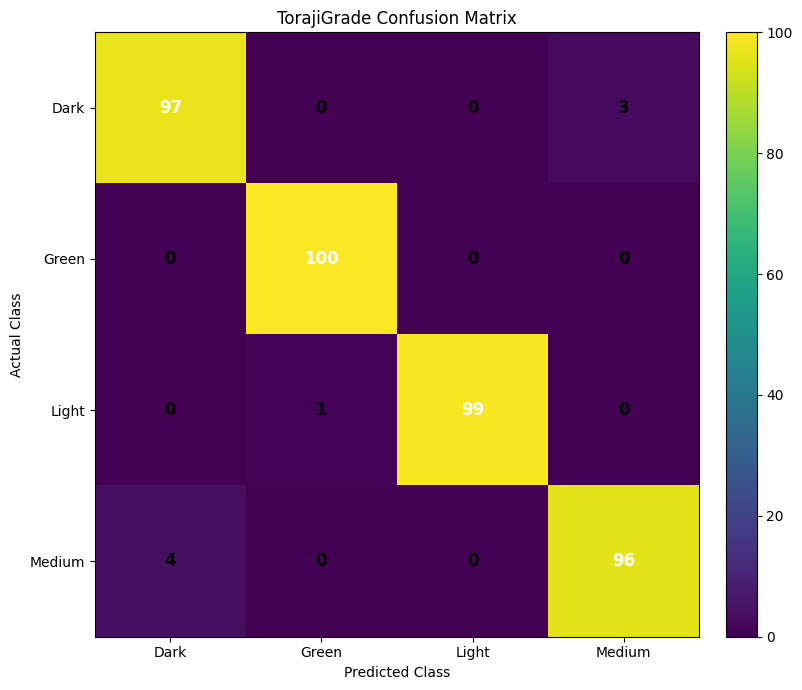

In [ ]:
# ============================================================
# Plot Confusion Matrix
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

image = ax.imshow(
    cm,
    interpolation="nearest",
)

ax.set_title(
    "TorajiGrade Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Actual Class"
)

ax.set_xticks(
    np.arange(len(CLASS_NAMES))
)

ax.set_yticks(
    np.arange(len(CLASS_NAMES))
)

ax.set_xticklabels(
    CLASS_NAMES
)

ax.set_yticklabels(
    CLASS_NAMES
)

# Add values inside matrix.
threshold = cm.max() / 2.0

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):

        ax.text(
            col,
            row,
            str(cm[row, col]),
            ha="center",
            va="center",
            color="white" if cm[row, col] > threshold else "black",
            fontsize=12,
            fontweight="bold",
        )

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

fig.tight_layout()

CONFUSION_MATRIX_PATH = Path(
    "/content/torajigrade_confusion_matrix.png"
)

fig.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


In [ ]:
# ============================================================
# Save evaluation metrics as JSON
# ============================================================

evaluation_results = {
    "model": str(MODEL_PATH),
    "dataset": str(TEST_DIR),
    "device": str(device),
    "num_samples": int(len(y_true)),
    "accuracy": float(accuracy),
    "accuracy_percentage": round(
        float(accuracy * 100),
        2,
    ),
    "macro_precision": float(
        precision.mean()
    ),
    "macro_recall": float(
        recall.mean()
    ),
    "macro_f1": float(
        f1.mean()
    ),
    "weighted_f1": float(
        np.average(
            f1,
            weights=support,
        )
    ),
    "classes": {
        class_name: {
            "precision": float(precision[index]),
            "recall": float(recall[index]),
            "f1_score": float(f1[index]),
            "support": int(support[index]),
        }
        for index, class_name in enumerate(CLASS_NAMES)
    },
    "confusion_matrix": cm.tolist(),
}


METRICS_JSON_PATH = Path(
    "/content/torajigrade_evaluation.json"
)

with METRICS_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_results,
        file,
        indent=4,
        ensure_ascii=False,
    )

In [ ]:
# ============================================================
# Final summary
# ============================================================

print()
print("=" * 72)
print("EVALUATION COMPLETE")
print("=" * 72)

print(
    f"Accuracy       : {accuracy * 100:.2f}%"
)

print(
    f"Macro F1       : {f1.mean() * 100:.2f}%"
)

print(
    f"Green F1       : {green_f1 * 100:.2f}%"
)

print(
    f"Confusion Matrix: "
    f"{CONFUSION_MATRIX_PATH}"
)

print(
    f"Metrics JSON    : "
    f"{METRICS_JSON_PATH}"
)


EVALUATION COMPLETE
Accuracy       : 98.00%
Macro F1       : 98.00%
Green F1       : 99.50%
Confusion Matrix: /content/torajigrade_confusion_matrix.png
Metrics JSON    : /content/torajigrade_evaluation.json


## SIMPAN ke Gdrive

In [ ]:
DRIVE_OUTPUT = Path(
    "/content/drive/MyDrive/Dataset/dataset-AIC/evaluation"
)

DRIVE_OUTPUT.mkdir(
    parents=True,
    exist_ok=True
)

# Confusion Matrix
shutil.copy2(
    "/content/torajigrade_confusion_matrix.png",
    DRIVE_OUTPUT / "torajigrade_confusion_matrix.png"
)

# Evaluation Metrics JSON
shutil.copy2(
    "/content/torajigrade_evaluation.json",
    DRIVE_OUTPUT / "torajigrade_evaluation.json"
)

print("Hasil evaluasi berhasil disimpan ke:")
print(DRIVE_OUTPUT)

Hasil evaluasi berhasil disimpan ke:
/content/drive/MyDrive/Dataset/dataset-AIC/evaluation


Testing Model

In [ ]:
# ============================================================
# TorajiGrade - Unseen Image Inference Test
# ============================================================

from google.colab import files
from pathlib import Path
import io

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms


# ============================================================
# Configuration
# ============================================================

MODEL_PATH = Path(
    "/content/best_torajigrade_model.pth"
)

CLASS_NAMES = [
    "Dark",
    "Green",
    "Light",
    "Medium",
]

IMAGE_SIZE = (224, 224)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# ============================================================
# Upload image
# ============================================================

print("Upload gambar kopi yang BELUM pernah digunakan dalam")
print("train/ maupun test/ dataset.")
print()

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("Tidak ada gambar yang di-upload.")

image_name = next(iter(uploaded))
image_bytes = uploaded[image_name]

print(f"Gambar: {image_name}")


# ============================================================
# Preprocessing
# ============================================================

transform = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)


# ============================================================
# Build model
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = models.mobilenet_v3_small(
    weights=None
)

in_features = model.classifier[3].in_features

model.classifier[3] = nn.Linear(
    in_features=in_features,
    out_features=4,
)


# ============================================================
# Load best model
# ============================================================

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model tidak ditemukan: {MODEL_PATH}"
    )

state_dict = torch.load(
    MODEL_PATH,
    map_location=device,
)

model.load_state_dict(
    state_dict,
    strict=True,
)

model = model.to(device)
model.eval()


# ============================================================
# Prepare image
# ============================================================

image = Image.open(
    io.BytesIO(image_bytes)
).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)


# ============================================================
# Inference
# ============================================================

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1,
    )

    confidence, predicted_index = torch.max(
        probabilities,
        dim=1,
    )


predicted_index = int(
    predicted_index.item()
)

confidence = float(
    confidence.item()
)

predicted_class = CLASS_NAMES[
    predicted_index
]


# ============================================================
# Result
# ============================================================

print()
print("=" * 60)
print("TORAJIGRADE INFERENCE RESULT")
print("=" * 60)

print(
    f"Predicted Class : {predicted_class}"
)

print(
    f"Confidence      : {confidence * 100:.2f}%"
)

print(
    f"Class Index     : {predicted_index}"
)

print("=" * 60)

Upload gambar kopi yang BELUM pernah digunakan dalam
train/ maupun test/ dataset.



Saving Screenshot from 2026-08-21 11-15-11.png to Screenshot from 2026-08-21 11-15-11.png
Gambar: Screenshot from 2026-08-21 11-15-11.png

TORAJIGRADE INFERENCE RESULT
Predicted Class : Medium
Confidence      : 89.12%
Class Index     : 3
